# XGBoost Modelling

Aim to train an XGBoost model to predict the outcomes of international football matches.

### Prerequisites

In [157]:
# Import packages
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import log_loss, accuracy_score, f1_score, classification_report, brier_score_loss
from scipy.stats import skellam
import matplotlib.pyplot as plt
import seaborn as sns

In [145]:
# Load the data
results_df = pd.read_csv('results_with_stats.csv')

results_df

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,...,away_elo,away_elo_num_matches,home_goals_scored_ema_short,home_goals_conceeded_ema_short,away_goals_scored_ema_short,away_goals_conceeded_ema_short,home_goals_scored_ema_long,home_goals_conceeded_ema_long,away_goals_scored_ema_long,away_goals_conceeded_ema_long
0,0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,...,1500.000000,0,1.400000,1.400000,1.400000,1.400000,1.400000,1.400000,1.400000,1.400000
1,1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,...,1497.198700,1,1.120000,1.120000,1.120000,1.120000,1.260000,1.260000,1.260000,1.260000
2,2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,...,1513.377469,2,1.296000,1.696000,1.696000,1.296000,1.334000,1.534000,1.534000,1.334000
3,3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,...,1494.545054,3,1.556800,1.436800,1.436800,1.556800,1.480600,1.400600,1.400600,1.480600
4,4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,...,1502.366892,4,1.549440,1.645440,1.645440,1.549440,1.460540,1.532540,1.532540,1.460540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49210,49210,2026-03-31,Kosovo,Turkey,0.0,1.0,FIFA World Cup qualification,Pristina,Kosovo,False,...,1928.475277,639,2.019177,1.226622,2.169170,1.217266,1.831125,1.150950,2.069689,1.337602
49211,49211,2026-03-31,Czech Republic,Denmark,2.0,2.0,FIFA World Cup qualification,Prague,Czech Republic,False,...,1909.312733,871,2.151352,0.995585,2.806384,1.246019,1.943938,1.050872,2.343322,1.112322
49212,49212,2026-03-31,Cameroon,China PR,2.0,0.0,FIFA Series,Melbourne,Australia,True,...,1564.342900,699,0.881513,0.963069,1.133626,1.161105,1.108241,0.822458,1.040085,1.362738
49213,49213,2026-03-31,Australia,Curaçao,5.0,1.0,FIFA Series,Melbourne,Australia,False,...,1610.650463,382,1.050046,1.008136,1.753842,0.835667,1.421753,0.849348,1.865160,0.873923


## Data Preparation

Wish to perform some further data preparation. This includes:

* Creating a column that specifies the results
* Adding a column to represent home advantage
* Duplicating rows, with teams permuted to enforce symmetry

In [146]:
# Remove matches where stats not yet stabilised
min_matches = 30
results_df = results_df[results_df['home_elo_num_matches']>=min_matches]
results_df = results_df[results_df['away_elo_num_matches']>=min_matches]

print(f"{len(results_df)} matches in data remaining")

43134 matches in data remaining


In [147]:
# Add winner and home advantage columns
winner_col = []
home_adv_col = []

for _, row in results_df.iterrows():

    # Get score
    home_score = row['home_score']
    away_score = row['away_score']

    # Determine winner
    if home_score > away_score:
        winner_col.append(0)
    elif home_score < away_score:
        winner_col.append(2)
    else:
        winner_col.append(1)

    # Determine home advantage
    neutral_ground = row['neutral']

    if not neutral_ground:
        home_adv_col.append(1)
    else:
        home_adv_col.append(0)

# Add to dataframe
results_df['winner'] = winner_col
results_df['home_adv'] = home_adv_col

In [148]:
# Duplicate and swap columns to enforce symmetry

def mirror_data(input_df, merge_dataframes=True):

    # Define the pairs to swap
    swap_pairs = [
        ('home_team', 'away_team'),
        ('home_score', 'away_score'),
        ('home_elo', 'away_elo'),
        ('home_elo_num_matches', 'away_elo_num_matches'),
        ('home_goals_scored_ema_short', 'away_goals_scored_ema_short'),
        ('home_goals_conceeded_ema_short', 'away_goals_conceeded_ema_short'),
        ('home_goals_scored_ema_long', 'away_goals_scored_ema_long'),
        ('home_goals_conceeded_ema_long', 'away_goals_conceeded_ema_long'),
    ]

    # Create a rename map
    rename_map = {}
    for home_col, away_col in swap_pairs:
        rename_map[home_col] = away_col
        rename_map[away_col] = home_col

    # Create a copy of the dataframe
    df_mirrored = input_df.copy()

    # Rename columns
    df_mirrored = df_mirrored.rename(columns=rename_map)

    # Flip the winner
    if 'winner' in df_mirrored:
        df_mirrored['winner'] = 2 - df_mirrored['winner']

    # Flip the home advantage
    df_mirrored['home_adv'] = -1 * df_mirrored['home_adv']

    # Combine together
    if merge_dataframes:
        combined_results_df = pd.concat([input_df, df_mirrored], axis=0)
        combined_results_df = combined_results_df.sort_values('date').reset_index(drop=True)
    else:
        combined_results_df = df_mirrored
    

    # Create a match ID column
    combined_results_df = combined_results_df.rename(columns={"Unnamed: 0": "match_id"})

    return combined_results_df

## Simple Classifier

As a first model, will train an XGBoost classifier to predict the outcome of a match (home win, away win, draw). The resulting probabilities can then be used during the simulation. This provides an intermediate stage from the initial Elo model, where it only aims to predict outcomes of matches but doesn't simulate the number of goals scored.

In [149]:
# # Define the input columns
# input_columns = [
#     'home_elo', 'away_elo', 
#     'home_goals_scored_ema_short', 'home_goals_conceeded_ema_short',
#     'away_goals_scored_ema_short', 'away_goals_conceeded_ema_short',
#     'home_goals_scored_ema_long', 'home_goals_conceeded_ema_long',
#     'away_goals_scored_ema_long', 'away_goals_conceeded_ema_long',
#     'home_adv'
# ]

# # Create X and y dataframes
# X_df = combined_results_df[input_columns]
# y_df = combined_results_df['winner']

# tscv = TimeSeriesSplit(n_splits=5)

# for train_idx, test_idx in tscv.split(X_df):

#     # Create the dataframes
#     X_train, X_test = X_df.iloc[train_idx], X_df.iloc[test_idx]
#     y_train, y_test = y_df.iloc[train_idx], y_df.iloc[test_idx]

#     # Create the model
#     model = xgb.XGBClassifier(
#         objective='multi:softprob',
#         eval_metric='mlogloss'
#     )

#     # Fit the model
#     model.fit(X_train, y_train)

#     # Get the probabilities for all 3 classes (Home, Draw, Away)
#     probs = model.predict_proba(X_test)
#     y_pred = model.predict(X_test)  # hard predictions (class with maximum prob)

#     # Calculate metrics
#     accuracy = accuracy_score(y_test, y_pred)
#     f1_macro = f1_score(y_test, y_pred, average='macro')
#     f1_weighted = f1_score(y_test, y_pred, average='weighted')

#     is_home_win_actual = (y_test == 0).astype(int)
#     is_draw_actual = (y_test == 1).astype(int)
#     is_away_win_actual = (y_test == 2).astype(int)

#     prob_home_win = probs[:, 0]
#     prob_draw = probs[:, 1]
#     prob_away_win = probs[:, 2]

#     home_brier = brier_score_loss(is_home_win_actual, prob_home_win)
#     draw_brier = brier_score_loss(is_draw_actual, prob_draw)
#     away_brier = brier_score_loss(is_away_win_actual, prob_away_win)


#     # Simulate a random model
#     train_outcome_freqs = y_train.value_counts()
#     home_win_count, draw_count, away_win_count = train_outcome_freqs[0], train_outcome_freqs[1], train_outcome_freqs[2]
#     home_win_perc = home_win_count / len(y_train)
#     draw_perc = draw_count / len(y_train)
#     away_win_perc = away_win_count / len(y_train)
#     # Calculate Brier scores
#     home_brier_random = brier_score_loss(is_home_win_actual, [home_win_perc]*len(is_home_win_actual))
#     draw_brier_random = brier_score_loss(is_draw_actual, [draw_perc]*len(is_draw_actual))
#     away_brier_random = brier_score_loss(is_away_win_actual, [away_win_perc]*len(is_away_win_actual))

#     print(f"Fold Log Loss: {log_loss(y_test, probs)}")
#     print(f"Home Win Brier: {home_brier} | {home_brier_random}")
#     print(f"Draw Brier: {draw_brier} | {draw_brier_random}")
#     print(f"Away Win Brier: {away_brier} | {away_brier_random}")
#     # print(f"Fold Accuracy: {accuracy}")
#     # print(f"Fold F1 Macro: {f1_macro}")
#     print(classification_report(y_test, y_pred, target_names=['Home Win', 'Draw', 'Away Win']))
#     print()
print("Old code, had errors")

Old code, had errors


**Dicussion of above code, which had errors in it that hid some model behaviour**

From the above metrics, we see that the F1 scores for home and away wins is much higher than for draws, likely due to the relative rarity of draws leading the model to be reluctant to predict a draw (evident in the extremely low recall). However, for Monte Carlo simulation, we care more about the actual probabilities than which outcome had the greatest probability.

Therefore, the Brier scores are calculated, since they account for the predicted probability regardless of if it was the highest probability outcome. Additionally, the Brier scores for a model that predicts probabilities equal to the frequencies of outcomes in the training data are calculated. For home and away wins, we see lower Brier scores than for the random model, suggesting the trained model has gained some predictive power. However, for draws, the Brier scores are approximately equal, suggesting little ability to predict draws has been gained.

Whilst this is unfortunate, it is also somewhat expected. Draws typically happen due to a failure to convert from one (or both) teams, and can be challenging to predict prior to a match (beyond saying a draw is probably less likely when there is a big mismatch in teams strength). Therefore, provided the model still predicts draws roughly in line with the historical rate, draws should be properly reflected throughout the Monte Carlo simulation.

In [150]:
# V2, fixed duplication in test set so only duplicate training rows
    
all_model_results = {
    "Random": {},
    "Classifier": {},
    "Regressor": {}
}

# Define the input columns
input_columns = [
    'home_elo', 'away_elo', 
    'home_goals_scored_ema_short', 'home_goals_conceeded_ema_short',
    'away_goals_scored_ema_short', 'away_goals_conceeded_ema_short',
    'home_goals_scored_ema_long', 'home_goals_conceeded_ema_long',
    'away_goals_scored_ema_long', 'away_goals_conceeded_ema_long',
    'home_adv'
]

# Create X and y dataframes
# X_df = combined_results_df[input_columns]
# y_df = combined_results_df['winner']

tscv = TimeSeriesSplit(n_splits=5)

for fold_num, (train_idx, test_idx) in enumerate(tscv.split(results_df)):

    # Split the dataset
    train_df, test_df = results_df.iloc[train_idx], results_df.iloc[test_idx]

    # Duplicate rows in the training dataset
    train_df = mirror_data(train_df)

    # Create the datasets
    X_train, y_train = train_df[input_columns], train_df['winner']
    X_test, y_test = test_df[input_columns], test_df['winner']

    # Create the model
    model = xgb.XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss'
    )

    # Fit the model
    model.fit(X_train, y_train)

    # Get the probabilities for all 3 classes (Home, Draw, Away)
    probs = model.predict_proba(X_test)
    y_pred = model.predict(X_test)  # hard predictions (class with maximum prob)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    is_home_win_actual = (y_test == 0).astype(int)
    is_draw_actual = (y_test == 1).astype(int)
    is_away_win_actual = (y_test == 2).astype(int)

    prob_home_win = probs[:, 0]
    prob_draw = probs[:, 1]
    prob_away_win = probs[:, 2]

    home_brier = brier_score_loss(is_home_win_actual, prob_home_win)
    draw_brier = brier_score_loss(is_draw_actual, prob_draw)
    away_brier = brier_score_loss(is_away_win_actual, prob_away_win)


    # Simulate a random model
    train_outcome_freqs = y_train.value_counts()
    home_win_count, draw_count, away_win_count = train_outcome_freqs[0], train_outcome_freqs[1], train_outcome_freqs[2]
    home_win_perc = home_win_count / len(y_train)
    draw_perc = draw_count / len(y_train)
    away_win_perc = away_win_count / len(y_train)
    # Calculate Brier scores
    home_brier_random = brier_score_loss(is_home_win_actual, [home_win_perc]*len(is_home_win_actual))
    draw_brier_random = brier_score_loss(is_draw_actual, [draw_perc]*len(is_draw_actual))
    away_brier_random = brier_score_loss(is_away_win_actual, [away_win_perc]*len(is_away_win_actual))

    print(f"Fold Log Loss: {log_loss(y_test, probs)}")
    print(f"Home Win Brier: {home_brier} | {home_brier_random}")
    print(f"Draw Brier: {draw_brier} | {draw_brier_random}")
    print(f"Away Win Brier: {away_brier} | {away_brier_random}")
    # print(f"Fold Accuracy: {accuracy}")
    # print(f"Fold F1 Macro: {f1_macro}")
    print(classification_report(y_test, y_pred, target_names=['Home Win', 'Draw', 'Away Win']))
    print()

    all_model_results['Random'][fold_num] = {
        'Home Win Brier': home_brier_random,
        "Draw Brier": draw_brier_random,
        "Away Win Brier": away_brier_random
    }
    all_model_results['Classifier'][fold_num] = {
        'Home Win Brier': home_brier,
        "Draw Brier": draw_brier,
        "Away Win Brier": away_brier,
        "Classification Report": classification_report(y_test, y_pred, target_names=['Home Win', 'Draw', 'Away Win'],output_dict=True,zero_division=0)
    }

Fold Log Loss: 1.0609318121423736
Home Win Brier: 0.23071074485778809 | 0.25542378900269214
Draw Brier: 0.21070975065231323 | 0.1963460349936876
Away Win Brier: 0.18151816725730896 | 0.21171570505556503
              precision    recall  f1-score   support

    Home Win       0.57      0.74      0.65      3409
        Draw       0.28      0.12      0.17      1884
    Away Win       0.45      0.47      0.46      1896

    accuracy                           0.51      7189
   macro avg       0.44      0.44      0.43      7189
weighted avg       0.46      0.51      0.47      7189


Fold Log Loss: 0.9422876756979739
Home Win Brier: 0.20614199340343475 | 0.26142264230132733
Draw Brier: 0.18772605061531067 | 0.18616145251819308
Away Win Brier: 0.1619202047586441 | 0.20813603638508862
              precision    recall  f1-score   support

    Home Win       0.60      0.82      0.70      3522
        Draw       0.31      0.11      0.16      1776
    Away Win       0.52      0.49      0.51      

From the above metrics, we see that the F1 scores for home and away wins is much higher than for draws, likely due to the relative rarity of draws leading the model to be reluctant to predict a draw (evident in the extremely low recall). However, for Monte Carlo simulation, we care more about the actual probabilities than which outcome had the greatest probability.

Therefore, the Brier scores are calculated, since they account for the predicted probability regardless of if it was the highest probability outcome. Additionally, the Brier scores for a model that predicts probabilities equal to the frequencies of outcomes in the training data are calculated. For home and away wins, we see lower Brier scores than for the random model, suggesting the trained model has gained some predictive power. However, for draws, the Brier scores are approximately equal, suggesting little ability to predict draws has been gained.

Whilst this is unfortunate, it is also somewhat expected. Draws typically happen due to a failure to convert from one (or both) teams, and can be challenging to predict prior to a match (beyond saying a draw is probably less likely when there is a big mismatch in teams strength). Therefore, provided the model still predicts draws roughly in line with the historical rate, draws should be properly reflected throughout the Monte Carlo simulation.

We also see some difference in the metrics for home and away wins, despite both beating the random Brier. Therefore, some checks can be performed to see if the model has learned the desired symmetry, by permuting teams in the test dataset and comparing the resulting predicted probabilties (to do).

In [151]:
# Symmetry checks...

## Goal Scoring Simulation

In an attempt to model the goals scored, which will allow for higher certainty in the simulation (ie. can determine exactly which teams would qualify), will aim to develop a model that predicts the specific scoreline.

Inspired by Gemini's suggestions, will train two XGBRegressors to predicted the expected goals for the two teams in the match. The goals each team score can then be modelled by a Poisson distribution, with the mean equal to the expected goals. These distributions can then be drawn from during the simulation to determine the specific scoreline.

In [152]:
# Evaluation function
def classification_comparison(model, X_df, y_df, in_cols, fold_num):
    """ 
    Computes the same metrics as for the classificaiton model to
    enable a direct comparison.
    """
    global all_model_results

    all_probs = []
    all_actuals = []
    eval_results = {}

    # Create a mirrored copy of the data
    X_df_mirrored = mirror_data(X_df, merge_dataframes=False)
    X_df_mirrored = X_df_mirrored[in_cols]

    # Predict lambdas
    home_lambdas = model.predict(X_df)
    away_lambdas = model.predict(X_df_mirrored)
    
    # Get the scores
    home_goals = y_df['home_score']
    away_goals = y_df['away_score']

    # Calculate means
    mean_total_lambda = (home_lambdas + away_lambdas).mean()
    mean_total_goals = (home_goals + away_goals).mean()
    print(f"Mean lambda: {mean_total_lambda} | Mean goals: {mean_total_goals}")
    eval_results['mean_total_lambda'] = mean_total_lambda
    eval_results['mean_total_goals'] = mean_total_goals


    # Determine the class probabilities
    p_home = skellam.sf(0, home_lambdas, away_lambdas)
    p_draw = skellam.pmf(0, home_lambdas, away_lambdas)
    p_away = 1 - p_home - p_draw

    all_probs = [[h, d, a] for h, d, a in zip(p_home, p_draw, p_away)]

    for hg, ag in zip(home_goals, away_goals):

        if hg > ag:
            all_actuals.append(0)
        elif hg < ag:
            all_actuals.append(2)
        else:
            all_actuals.append(1)


    # Calculate the metrics
    prob_array = np.array(all_probs)
    hard_probs_array = prob_array.argmax(axis=1)
    actual_array = np.array(all_actuals)

    # accuracy = accuracy_score(actual_array, prob_array)
    # f1_macro = f1_score(actual_array, prob_array, average='macro')
    # f1_weighted = f1_score(actual_array, prob_array, average='weighted')

    is_home_win_actual = (actual_array == 0).astype(int)
    is_draw_actual = (actual_array == 1).astype(int)
    is_away_win_actual = (actual_array == 2).astype(int)

    prob_home_win = prob_array[:, 0]
    prob_draw = prob_array[:, 1]
    prob_away_win = prob_array[:, 2]

    home_brier = brier_score_loss(is_home_win_actual, prob_home_win)
    draw_brier = brier_score_loss(is_draw_actual, prob_draw)
    away_brier = brier_score_loss(is_away_win_actual, prob_away_win)

    print(f"Fold Log Loss: {log_loss(actual_array, prob_array)}")
    print(f"Home Win Brier: {home_brier}")
    print(f"Draw Brier: {draw_brier}")
    print(f"Away Win Brier: {away_brier}")
    # print(f"Fold Accuracy: {accuracy}")
    # print(f"Fold F1 Macro: {f1_macro}")
    print(classification_report(actual_array, hard_probs_array, target_names=['Home Win', 'Draw', 'Away Win']))
    print()

    all_model_results['Regressor'][fold_num] = {
        'Home Win Brier': home_brier,
        "Draw Brier": draw_brier,
        "Away Win Brier": away_brier,
        "Classification Report": classification_report(actual_array, hard_probs_array, target_names=['Home Win', 'Draw', 'Away Win'],output_dict=True,zero_division=0)
    }
    


In [153]:
# Define the input columns
input_columns = [
    'home_elo', 'away_elo', 
    'home_goals_scored_ema_short', 'home_goals_conceeded_ema_short',
    'away_goals_scored_ema_short', 'away_goals_conceeded_ema_short',
    'home_goals_scored_ema_long', 'home_goals_conceeded_ema_long',
    'away_goals_scored_ema_long', 'away_goals_conceeded_ema_long',
    'home_adv'
]


tscv = TimeSeriesSplit(n_splits=5)

for fold_num, (train_idx, test_idx) in enumerate(tscv.split(results_df)):

    # Split the dataset
    train_df, test_df = results_df.iloc[train_idx], results_df.iloc[test_idx]

    # Duplicate rows in the training dataset
    train_df = mirror_data(train_df)

    # Create the datasets
    X_train, y_train = train_df[input_columns], train_df['home_score']
    X_test, y_test = test_df[input_columns], test_df[['home_score', 'away_score']]

    # Create the model
    model = xgb.XGBRegressor(
        objective='count:poisson',

        # Standard hyperparameters (starting point)
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,

        # Help prevent overfitting
        subsample=0.8,
        colsample_bytree=0.8,

        # Evaluation metric
        eval_metric='poisson-nloglik',
        random_state=42
    )

    # Fit the model
    model.fit(X_train, y_train)


    ## Evaluate the Model ##

    classification_comparison(model, X_test, y_test, input_columns, fold_num)

    pred = model.predict(X_test)
    # print(pred)





Mean lambda: 2.7173163890838623 | Mean goals: 2.500208652107386
Fold Log Loss: 0.9538631523798644
Home Win Brier: 0.21159504685640626
Draw Brier: 0.19044873414439825
Away Win Brier: 0.16579237566629954
              precision    recall  f1-score   support

    Home Win       0.57      0.84      0.68      3409
        Draw       0.35      0.00      0.01      1884
    Away Win       0.48      0.54      0.51      1896

    accuracy                           0.54      7189
   macro avg       0.47      0.46      0.40      7189
weighted avg       0.49      0.54      0.46      7189


Mean lambda: 2.6641080379486084 | Mean goals: 2.7197106690777577
Fold Log Loss: 0.91281757761654
Home Win Brier: 0.20089749909101
Draw Brier: 0.18104724969758804
Away Win Brier: 0.1576098649481042
              precision    recall  f1-score   support

    Home Win       0.60      0.88      0.71      3522
        Draw       0.17      0.00      0.00      1776
    Away Win       0.52      0.56      0.54      1891

 

/Users/samroughley/Desktop/test/Personal Projects/World Cup 2026/world_cup_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/samroughley/Desktop/test/Personal Projects/World Cup 2026/world_cup_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/samroughley/Desktop/test/Personal Projects/World Cup 2026/world_cup_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 

Mean lambda: 2.674805164337158 | Mean goals: 2.629851161496731
Fold Log Loss: 0.9059355687633605
Home Win Brier: 0.19783213785855133
Draw Brier: 0.17735202774519931
Away Win Brier: 0.1597276611896577
              precision    recall  f1-score   support

    Home Win       0.60      0.86      0.70      3437
        Draw       0.00      0.00      0.00      1726
    Away Win       0.53      0.59      0.56      2026

    accuracy                           0.58      7189
   macro avg       0.38      0.48      0.42      7189
weighted avg       0.44      0.58      0.49      7189




/Users/samroughley/Desktop/test/Personal Projects/World Cup 2026/world_cup_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/samroughley/Desktop/test/Personal Projects/World Cup 2026/world_cup_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/samroughley/Desktop/test/Personal Projects/World Cup 2026/world_cup_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 

Mean lambda: 2.721632480621338 | Mean goals: 2.702879399081931
Fold Log Loss: 0.8651468315618642
Home Win Brier: 0.18447701849717968
Draw Brier: 0.17128316688940884
Away Win Brier: 0.15210269421402808
              precision    recall  f1-score   support

    Home Win       0.62      0.88      0.73      3425
        Draw       0.00      0.00      0.00      1657
    Away Win       0.58      0.64      0.61      2107

    accuracy                           0.61      7189
   macro avg       0.40      0.51      0.45      7189
weighted avg       0.47      0.61      0.52      7189




/Users/samroughley/Desktop/test/Personal Projects/World Cup 2026/world_cup_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/samroughley/Desktop/test/Personal Projects/World Cup 2026/world_cup_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/samroughley/Desktop/test/Personal Projects/World Cup 2026/world_cup_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 

The above results seem to show reasonable performance when using this model as a 3-class classifier. The warnings present in the output are due to some test folds containing no predicted draws. This is not particularly concerning, as all it means is the model never predicts a draw with the highest probability, a fairly justifiable position.

The values of the metrics do seem strong, however a more detailed comparison with the simple classifier model can be found in the next section.

To get a gauge of the scorline prediction, we see that the mean number of expected goals is very close with that of the actual goals scored, suggesting the model does have a good understanding of scorelines. A more detailed investigation of the scoreline predictions could be performed, however given there are no other models to compare with currently, it is not the optimal use of time.

## Model Comparisons

Wish to compare directly compare the performances of the two models above, along with the random model.

In [155]:
all_model_results

{'Random': {0: {'Home Win Brier': 0.25542378900269214,
   'Draw Brier': 0.1963460349936876,
   'Away Win Brier': 0.21171570505556503},
  1: {'Home Win Brier': 0.26142264230132733,
   'Draw Brier': 0.18616145251819308,
   'Away Win Brier': 0.20813603638508862},
  2: {'Home Win Brier': 0.2587713963919876,
   'Draw Brier': 0.18172132421398618,
   'Away Win Brier': 0.21274026029005064},
  3: {'Home Win Brier': 0.2590316267839649,
   'Draw Brier': 0.18244776644531635,
   'Away Win Brier': 0.21214774398911757},
  4: {'Home Win Brier': 0.25865624714780694,
   'Draw Brier': 0.17743929231768424,
   'Away Win Brier': 0.2148178850313441}},
 'Classifier': {0: {'Home Win Brier': 0.23071074485778809,
   'Draw Brier': 0.21070975065231323,
   'Away Win Brier': 0.18151816725730896,
   'Classification Report': {'Home Win': {'precision': 0.5729190292583353,
     'recall': 0.7409797594602523,
     'f1-score': 0.6462010744435918,
     'support': 3409.0},
    'Draw': {'precision': 0.27970297029702973,
     

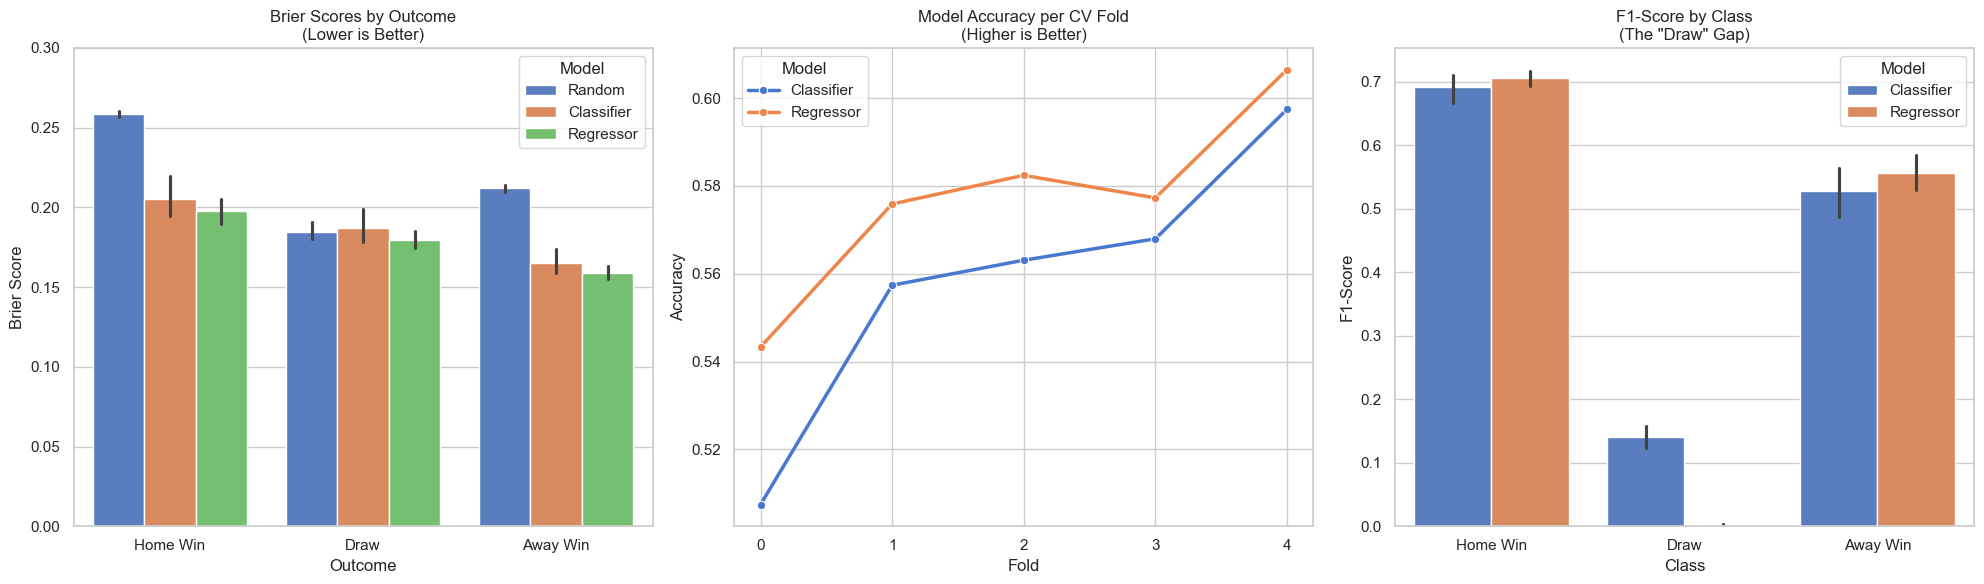

In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your 'results_dict' is already defined in your environment
# If not, ensure it is named exactly 'results_dict'

def plot_model_results(results_dict):
    brier_data = []
    acc_data = []
    f1_data = []

    # 1. Process the dictionary into flat lists for DataFrames
    for model_name, folds in results_dict.items():
        for fold_idx, data in folds.items():
            # Extract Brier Scores
            for outcome in ['Home Win', 'Draw', 'Away Win']:
                key = f'{outcome} Brier'
                brier_data.append({
                    'Model': model_name, 
                    'Fold': fold_idx, 
                    'Outcome': outcome, 
                    'Brier Score': data.get(key)
                })
            
            # Extract Accuracy and F1 from Classification Report
            if 'Classification Report' in data:
                report = data['Classification Report']
                acc_data.append({
                    'Model': model_name, 
                    'Fold': fold_idx, 
                    'Accuracy': report.get('accuracy')
                })
                
                for cls in ['Home Win', 'Draw', 'Away Win']:
                    f1_val = report.get(cls, {}).get('f1-score', 0)
                    f1_data.append({
                        'Model': model_name, 
                        'Class': cls, 
                        'F1-Score': f1_val
                    })

    # 2. Create DataFrames
    df_brier = pd.DataFrame(brier_data)
    df_acc = pd.DataFrame(acc_data)
    df_f1 = pd.DataFrame(f1_data)

    # 3. Set Plotting Style
    sns.set_theme(style="whitegrid", palette="muted")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # --- Plot 1: Brier Scores (Lower is Better) ---
    sns.barplot(ax=axes[0], data=df_brier, x='Outcome', y='Brier Score', hue='Model')
    axes[0].set_title('Brier Scores by Outcome\n(Lower is Better)')
    axes[0].set_ylim(0, 0.3)

    # --- Plot 2: Accuracy across Folds (Higher is Better) ---
    # Note: Random model doesn't have 'accuracy' in your dict, so we plot what we have
    sns.lineplot(ax=axes[1], data=df_acc, x='Fold', y='Accuracy', hue='Model', marker='o', linewidth=2.5)
    axes[1].set_title('Model Accuracy per CV Fold\n(Higher is Better)')
    axes[1].set_xticks(range(5))

    # --- Plot 3: F1-Score (Model Specificity) ---
    sns.barplot(ax=axes[2], data=df_f1, x='Class', y='F1-Score', hue='Model')
    axes[2].set_title('F1-Score by Class\n(The "Draw" Gap)')

    plt.tight_layout()
    plt.show()

# Execute the function
plot_model_results(all_model_results)

From the above plots, we can see how both the classification and regression models outperform the random model for home and away wins when measured by Brier score. As noticed earlier, the scores for draws are very similar, however this is not considered too significant on an issue as draws are intrinsically noisy and as such it is incredibly challenging to extract a meaningful signal for predicting draws.

Comparing the regression and classification models, we see that the regression model outperforms the classification model by all metrics with the exception of the draw F1 score. Again, extracting a signal for draws is challenging, and therefore such a result is not particularly concering, especially since F1 score only looks at the class with the highest probability.

Therefore, these results suggest that the regression model has superior classification performance when compared with the classifier, as well as being capable of predicting the scoreline. The regression model will therefore be used during the simulation.